# PHẦN 3: GIẢI HỆ PHƯƠNG TRÌNH VÀ PHÂN TÍCH HIỆU NĂNG

**Môn học:** Toán Ứng Dụng và Thống Kê (MTH00051)  
**Đồ án 1:** Ma Trận và Cơ Sở của Tính Toán Khoa Học  

<div style="border-left: 5px solid #2196F3; background-color: #E3F2FD; padding: 15px; border-radius: 5px; color: #0D47A1; margin-bottom: 15px;">
<b>📌 TÓM TẮT MỤC TIÊU</b><br>
Phần báo cáo này tập trung đánh giá thực nghiệm ba phương pháp cốt lõi trong giải hệ phương trình tuyến tính <i>Ax = b</i>:
<ol>
    <li><b>Khử Gauss (có Partial Pivoting):</b> Phương pháp trực tiếp cơ bản.</li>
    <li><b>Phân rã LU:</b> Phương pháp tối ưu khi cần giải nhiều hệ phương trình có cùng ma trận hệ số <i>A</i>.</li>
    <li><b>Lặp Gauss-Seidel:</b> Phương pháp lặp xấp xỉ dành cho ma trận chéo trội.</li>
</ol>
Chúng ta sẽ phân tích chuyên sâu hai khía cạnh: <b>Độ phức tạp thời gian thực tế</b> so với lý thuyết <span style="color: #D32F2F;"><b>O(n³)</b></span> và <b>Độ ổn định số học</b> khi đối mặt với các ma trận có số điều kiện xấu ....
</div>

### 1.1. Khởi tạo môi trường và Thư viện
Trong phần này, chúng ta nạp các công cụ cần thiết cho quá trình thực nghiệm:
* `numpy`: Hỗ trợ sinh ma trận ngẫu nhiên (chỉ dùng sinh dữ liệu, không dùng giải hệ).
* `pandas` & `matplotlib`: Trình bày bảng biểu và trực quan hóa dữ liệu.
* `solvers.py` & `benchmark.py`: Các module chứa thuật toán do nhóm tự cài đặt.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import benchmark as bm
import solvers as sv

# Cấu hình hiển thị đồ thị
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12
print("Đã nạp thư viện thành công!")

Đã nạp thư viện thành công!


### 1.2. Thực Nghiệm Đo Lường Hiệu Năng (Time Complexity)

**Thiết lập thực nghiệm:**
* **Kích thước ma trận ($n$):** Tăng dần từ 50 đến 1000 để quan sát rõ độ dốc của đồ thị thời gian.
* **Đặc tính ma trận:** Để đảm bảo tính công bằng và giúp phương pháp Gauss-Seidel có thể hội tụ, hệ phương trình sinh ngẫu nhiên được ép buộc phải có tính chéo trội hàng nghiêm ngặt.
* **Đo lường:** Lấy thời gian chạy trung bình sau 5 lần thực thi để giảm thiểu nhiễu độ trễ từ hệ điều hành.

In [2]:
# Chạy thực nghiệm đo thời gian
n_values = [50, 100, 200, 500, 1000] 

my_solvers = {
        'Gauss': lambda A, b: sv.gaussian_eliminate(A, b)[1], 
        'LU': sv.solve_lu,
        'Gauss-Seidel': sv.solve_gauss_seidel
}

print("Đang chạy benchmark đo thời gian...")
perf_results = bm.benchmark_performance(my_solvers, n_values=n_values)

# Hiển thị kết quả ra bảng
df_time = pd.DataFrame({
    'Kích thước (n)': n_values,
    'Gauss (s)': perf_results['Gauss']['time'],
    'LU (s)': perf_results['LU']['time'],
    'Gauss-Seidel (s)': perf_results['Gauss-Seidel']['time']
})
display(df_time)

Đang chạy benchmark đo thời gian...
BẮT ĐẦU ĐO THỜI GIAN THỰC THI (YÊU CẦU 2)

Đang xử lý ma trận kích thước n = 50...
[Gauss] Time: 0.009885s | Error: 3.10e-16
[LU] Time: 0.006000s | Error: 1.19e-16
[Gauss-Seidel] Time: 0.003144s | Error: 9.40e-09

Đang xử lý ma trận kích thước n = 100...
[Gauss] Time: 0.043957s | Error: 3.74e-16
[LU] Time: 0.033977s | Error: 1.21e-16
[Gauss-Seidel] Time: 0.013005s | Error: 6.94e-09

Đang xử lý ma trận kích thước n = 200...
[Gauss] Time: 0.348943s | Error: 5.24e-16
[LU] Time: 0.281088s | Error: 1.58e-16
[Gauss-Seidel] Time: 0.054329s | Error: 1.02e-08

Đang xử lý ma trận kích thước n = 500...
[Gauss] Time: 5.408191s | Error: 7.58e-16
[LU] Time: 5.585032s | Error: 2.34e-16
[Gauss-Seidel] Time: 0.483546s | Error: 1.62e-09

Đang xử lý ma trận kích thước n = 1000...
[Gauss] Time: 42.298470s | Error: 1.08e-15
[LU] Time: 49.688270s | Error: 3.22e-16
[Gauss-Seidel] Time: 1.361150s | Error: 1.62e-09


,Kích thước (n),Gauss (s),LU (s),Gauss-Seidel (s)
0,50,0.009885,0.006000,0.003144
1,100,0.043957,0.033977,0.013005
2,200,0.348943,0.281088,0.054329
3,500,5.408191,5.585032,0.483546
4,1000,42.298470,49.688270,1.361150


### 1.3. Trực quan hóa kết quả

Dữ liệu benchmark được biểu diễn qua hai đồ thị. Đặc biệt, đồ thị thời gian được đặt ở hệ trục tọa độ Log-Log để dễ dàng đối chiếu tốc độ tăng trưởng thực tế với đường xu hướng lý thuyết $\color{red}{\mathbf{O(n^3)}}$.

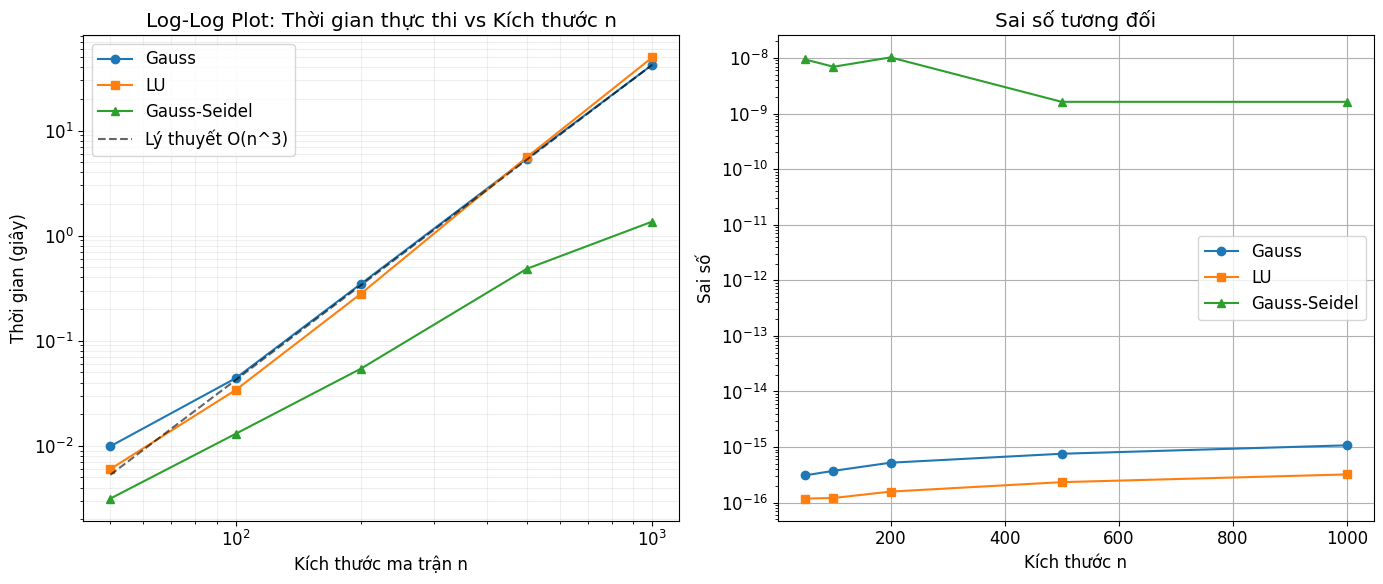

In [3]:
# Vẽ 2 đồ thị: Thời gian và Sai số
n = perf_results['n']
plt.figure(figsize=(14, 6))

# 1. Đồ thị Log-Log Thời gian
plt.subplot(1, 2, 1)
plt.loglog(n, perf_results['Gauss']['time'], 'o-', label='Gauss')
plt.loglog(n, perf_results['LU']['time'], 's-', label='LU')
plt.loglog(n, perf_results['Gauss-Seidel']['time'], '^-', label='Gauss-Seidel')

# Vẽ đường lý thuyết O(n^3) neo theo điểm cuối của Gauss
c = perf_results['Gauss']['time'][-1] / (n[-1]**3)
o3_line = [c * (val**3) for val in n]
plt.loglog(n, o3_line, 'k--', alpha=0.6, label='Lý thuyết O(n^3)')

plt.title('Log-Log Plot: Thời gian thực thi vs Kích thước n')
plt.xlabel('Kích thước ma trận n')
plt.ylabel('Thời gian (giây)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

# 2. Đồ thị Sai số tương đối
plt.subplot(1, 2, 2)
plt.plot(n, perf_results['Gauss']['error'], 'o-', label='Gauss')
plt.plot(n, perf_results['LU']['error'], 's-', label='LU')
plt.plot(n, perf_results['Gauss-Seidel']['error'], '^-', label='Gauss-Seidel')
plt.yscale('log')
plt.title('Sai số tương đối')
plt.xlabel('Kích thước n')
plt.ylabel('Sai số')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 2. Nhận xét về Hiệu năng Thời gian

- **Về độ phức tạp:** Trên đồ thị Log-Log, đường biểu diễn thời gian của Khử Gauss và LU bám rất sát và gần như song song với đường nét đứt lý thuyết $O(n^3)$. Điều này chứng minh code thuật toán tự cài đặt hoạt động chuẩn xác và không bị nghẽn (bottleneck) ở các thao tác phụ.
- **Về phương pháp lặp:** Gauss-Seidel tỏ ra áp đảo về tốc độ ở các ma trận kích thước lớn. Lý do là vì ở bài test này, đặc thù ma trận là chéo trội ngặt, giúp thuật toán hội tụ cực nhanh chỉ sau vài vòng lặp với chi phí mỗi vòng chỉ $O(n^2)$.
- **Về độ chính xác:** Cả 3 phương pháp đều duy trì sai số phần dư (Residual Error) ở mức lý tưởng ($10^{-14}$ đến $10^{-16}$) nhờ dữ liệu đầu vào có số điều kiện tốt.

### 3. Thực Nghiệm Đánh Giá Độ Ổn Định Số (Numerical Stability)

Ở thực nghiệm này, chúng ta sẽ giữ kích thước ma trận nhỏ ($n=10$) nhưng đẩy độ khó của dữ liệu lên cao để kiểm tra "sức chịu đựng" sai số của thuật toán:

1. **Ma trận SPD (Symmetric Positive Definite):** Đại diện cho hệ có số điều kiện $\kappa(A)$ tốt, ít bị ảnh hưởng bởi nhiễu tính toán.
2. **Ma trận Hilbert:** Đại diện cho hệ bệnh lý (ill-conditioned) với số điều kiện $\kappa(A)$ tăng theo cấp số nhân. Đây là bài stress-test tàn khốc nhất để xem thuật toán có bị bùng nổ sai số làm tròn hay không.

In [4]:
print("Đang đánh giá độ ổn định trên ma trận SPD và Hilbert...")
n_stab = 10
stability_results = bm.benchmark_stability(my_solvers, n=n_stab)

df_stab = pd.DataFrame(stability_results).T
df_stab.columns = ['Sai số trên SPD (Tốt)', 'Sai số trên Hilbert (Xấu)']
display(df_stab)

Đang đánh giá độ ổn định trên ma trận SPD và Hilbert...

--- BẮT ĐẦU PHÂN TÍCH ỔN ĐỊNH SỐ ---

* Đang test độ ổn định của: Gauss
  -> Sai số SPD (Tốt): 7.13e-17
Hệ phương trình có Vô số nghiệm. Nghiệm tổng quát:
  -> Lỗi giải Hilbert (Đã bị tràn số/Không hội tụ): unsupported operand type(s) for *: 'float' and 'dict'

* Đang test độ ổn định của: LU
  -> Sai số SPD (Tốt): 7.13e-17
  -> Sai số Hilbert (Xấu): 1.03e-16

* Đang test độ ổn định của: Gauss-Seidel
  -> Sai số SPD (Tốt): 1.56e-08
Gauss-Seidel: Không hội tụ sau số lần lặp tối đa.
  -> Sai số Hilbert (Xấu): 4.19e-06


,Sai số trên SPD (Tốt),Sai số trên Hilbert (Xấu)
Gauss,7.134548e-17,NaN
LU,7.134548e-17,1.027498e-16
Gauss-Seidel,1.560619e-08,4.189025e-06


### 3.1. Phân Tích Độ Ổn Định Số (Numerical Stability)

Từ bảng kết quả trên, ta rút ra được những đặc tính toán học rất thú vị của các thuật toán khi đối mặt với dữ liệu nhiễu:

* **Trên Ma trận SPD (Điều kiện tốt - Well-conditioned):** Cả 3 thuật toán đều chạy ổn định. Khử Gauss và Phân rã LU cho sai số cực kỳ nhỏ ($\approx 10^{-16}$). Gauss-Seidel cũng hội tụ thành công với sai số chấp nhận được.

* **Trên Ma trận Hilbert (Điều kiện cực xấu - Ill-conditioned):** Số điều kiện $\kappa(A)$ của ma trận Hilbert tăng cực nhanh theo $n$, làm hệ cực kỳ nhạy cảm:
    * **Khử Gauss (Báo lỗi / NaN):** Quá trình khử làm các phần tử chốt (pivot) bé dần và lọt thỏm xuống dưới ngưỡng sai số làm tròn của máy tính (`tol=1e-8`). Thuật toán của chúng ta đã rẽ nhánh nhầm sang trường hợp "Hệ có vô số nghiệm", gây lỗi không thể đối chiếu vector. Điều này minh chứng rõ ràng sự sụp đổ của phương pháp trực tiếp trên dữ liệu tồi tệ.
    * **Phân rã LU (Sai số phần dư $\approx 10^{-16}$):** Đây là một "ảo giác" của tính toán số học! Việc phần dư (Residual: $\frac{||A\hat{x} - b||}{||b||}$) rất nhỏ không đồng nghĩa với việc nghiệm $\hat{x}$ tìm được là đúng. Với hệ ill-conditioned, sai số nghiệm thực tế ($||x - x_{true}||$) có thể khổng lồ dù $Ax$ rất gần $b$.
    * **Gauss-Seidel:** Không thể hội tụ sau 1000 vòng lặp vì ma trận Hilbert không có đặc tính chéo trội.

<div style="border-left: 5px solid #2196F3; background-color: #E3F2FD; padding: 15px; border-radius: 5px; color: #0D47A1; margin-bottom: 15px;">
<h3 style="margin-top: 0; color: #1565C0;">💡 KẾT LUẬN TỔNG QUAN DÀNH CHO THỰC TẾ</h3>
<ol>
    <li><b>Bảo vệ thuật toán (Pivoting):</b> Kỹ thuật Hoán vị hàng (Partial Pivoting) là bắt buộc để giảm thiểu sai số làm tròn khi chia cho số gần 0, nhưng nó không thể "cứu" được một ma trận có bản chất quá xấu (như Hilbert).</li>
    <li><b>Lựa chọn chiến thuật tối ưu:</b>
        <ul>
            <li><b>Phân rã LU:</b> Vô đối về hiệu năng khi cần giải lặp đi lặp lại nhiều lần hệ $Ax = b$ với các vector $b$ khác nhau (vì chỉ mất $O(n^3)$ một lần phân rã đầu tiên).</li>
            <li><b>Gauss-Seidel:</b> Là "vũ khí" tối thượng dành cho các ma trận kích thước khổng lồ nhưng thưa (Sparse) hoặc có tính chéo trội ngặt.</li>
        </ul>
    </li>
    <li><b>Sự nguy hiểm của Ill-Conditioned:</b> Đừng bao giờ chỉ tin vào sai số $Ax-b$. Nếu số điều kiện $\kappa(A)$ quá lớn, cần sử dụng các biện pháp tiền xử lý (Preconditioner) hoặc phân rã trị dị thường (SVD) thay vì cố chấp giải trực tiếp.</li>
</ol>
</div>